In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])

# Excluir columnas no deseadas (incluyendo year y posibles lags para evitar problemas de re-ejecución)
exclude_cols = ["quarter", "fecha", "municipio", "pib_mun_desestacionalizado", "pib_mun_trend", "log_pib_mun_trend", "year"]
medidas_base = [col for col in mont_rad_pib.columns if col not in exclude_cols and not col.endswith("_lag_1") and not col.endswith("_lag_2")]

for col in medidas_base:
    mont_rad_pib[col] = np.log(mont_rad_pib[col])


# Random Forest + OLS sin 'year' con LAGS

In [36]:
col = "Suma_de_radianza_trend_median"

mont_rad_pib[f"{col}_lag_1"] = mont_rad_pib[col].shift(1)
mont_rad_pib[f"{col}_lag_2"] = mont_rad_pib[col].shift(2)

medidas_con_lags = medidas_base.copy()
medidas_con_lags.extend([f"{col}_lag_1", f"{col}_lag_2"])

mont_rad_pib_clean = mont_rad_pib.dropna(subset=medidas_con_lags + ["log_pib_mun_trend"]).copy()

X = mont_rad_pib_clean[medidas_con_lags]
y = mont_rad_pib_clean["log_pib_mun_trend"]

# Configurar K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar métricas
metrics = {
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": [],
    "MSE_original": [],
    "RMSE_original": [],
    "MAE_original": [],
    "MAPE_original": []
}

# Iterar sobre los folds
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 1. Escalar datos
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=medidas_con_lags, index=X_train.index)
    
    X_test_scaled = scaler_X.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=medidas_con_lags, index=X_test.index)
    
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    # 2. Entrenar OLS en datos escalados de train
    X_train_ols = sm.add_constant(X_train_scaled)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_ols_train = ols_model.predict(X_train_ols)
    residuals_ols = y_train_scaled - y_hat_ols_train
    
    # 3. Entrenar RF en los residuales (SIN la constante)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        random_state=42
    )
    rf.fit(X_train_scaled, residuals_ols)
    
    # 4. Predicción en test
    # Predicción OLS
    X_test_ols = sm.add_constant(X_test_scaled)
    y_pred_ols_scaled = ols_model.predict(X_test_ols)
    
    # Predicción RF sobre residuales
    y_pred_rf_scaled = rf.predict(X_test_scaled)
    
    # Predicción híbrida (OLS + RF)
    y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled
    
    # Desescalar predicción
    y_pred_hybrid = scaler_y.inverse_transform(
        y_pred_hybrid_scaled.values.reshape(-1, 1)
    ).ravel()
    
    # 5. Calcular métricas en escala logarítmica
    mse_log = mean_squared_error(y_test, y_pred_hybrid)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test, y_pred_hybrid)
    mape_log = np.mean(np.abs((y_test - y_pred_hybrid) / y_test))
    
    # 6. Métricas en escala original (aplicar exp para revertir el log)
    y_test_original = np.exp(y_test)
    y_pred_original = np.exp(y_pred_hybrid)
    
    mse_original = mean_squared_error(y_test_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    mape_original = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original))
    
    # Guardar métricas
    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)
    metrics["MSE_original"].append(mse_original)
    metrics["RMSE_original"].append(rmse_original)
    metrics["MAE_original"].append(mae_original)
    metrics["MAPE_original"].append(mape_original)

# Convertir métricas a DataFrame y mostrar resumen
metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)


,MSE_log,RMSE_log,MAE_log,MAPE_log,MSE_original,RMSE_original,MAE_original,MAPE_original
mean,0.001551,0.038455,0.029809,0.002419,7.900131e+07,8671.082060,6750.490775,0.030007
std,0.000741,0.009526,0.006012,0.000492,3.759859e+07,2183.359672,1350.484941,0.006638


## TimeSplit CV

In [37]:
# Usar las features con lags ya definidas en el notebook
features = medidas_con_lags

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = mont_rad_pib_clean.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['log_pib_mun_trend']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
            n_estimators=100,
            max_leaf_nodes=None,
            max_depth=10,
            min_samples_leaf=1,
            min_samples_split=10,
            random_state=42
        )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df)
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred = np.array(y_pred_hybrid)

    # Métricas globales del fold (en escala logarítmica)
    mse_log = mean_squared_error(y_test_values, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_values, y_pred)
    mape_log = np.mean(np.abs((y_test_values - y_pred) / y_test_values))

    # Métricas en escala original
    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE_log': mse_log,
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'MAPE_log': mape_log,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print("Métricas globales promedio (Monterrey):")
print("="*60)
print(df_global_metrics.mean())
print("\n📋 Métricas por fold:")
print("="*60)
print(df_global_metrics)

# Agregar: imprimir media y std por medida, sin notación científica
print("\n" + "="*60)
print("Media y std por medida (Métricas entre folds):")
print("="*60)
media_std = df_global_metrics.agg(['mean', 'std']).T

# Mostrar todos los valores en formato decimal, no notación científica
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(media_std)



🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

Métricas globales promedio (Monterrey):
MSE_log     2.086233e-02
RMSE_log    1.222710e-01
MAE_log     1.086585e-01
MAPE_log    8.771995e-03
MSE         1.004181e+09
RMSE        2.717426e+04
MAE         2.422950e+04
MAPE        1.012325e+01
dtype: float64

📋 Métricas por fold:
    MSE_log  RMSE_log   MAE_log  MAPE_log           MSE          RMSE  \
0  0.005056  0.071104  0.059294  0.004822  2.219870e+08  14899.227041   
1  0.007046  0.083942  0.071037  0.005744  3.548227e+08  18836.736766   
2  0.010832  0.104078  0.093721  0.007579  6.637556e+08  25763.455572   
3  0.006048  0.077769  0.062566  0.005058  3.028030e+08  17401.235338   
4  0.075329  0.274462  0.256674  0.020657  3.477537e+09  58970.641123   

            MAE       MAPE  
0  12450.771162   5.684437  
1  15900.686695   6.763966  
2  23339.554127   9.937868  
3  14032.427102   5.965354  
4  55424

## Forecast

RMSE forecast (log): 0.094485
MSE forecast (log): 0.008927
MAE forecast (log): 0.093881


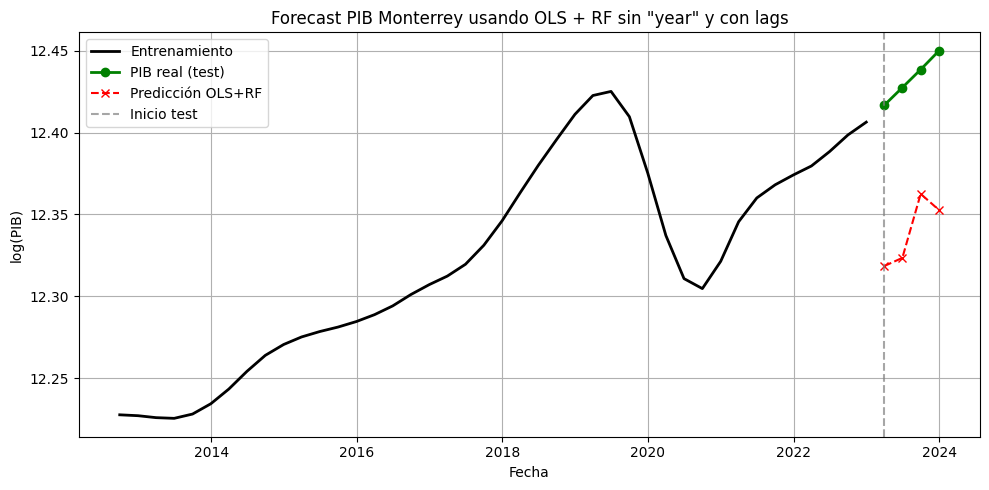

In [38]:
# -------- Forecast con modelo híbrido OLS + RF --------

# Selección de features correctas y consistentes
features = medidas_con_lags  # Usamos las mismas features sin year

# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib_clean.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['log_pib_mun_trend'].iloc[:-n_preds].astype(float)
    y_mun_test = df_mun['log_pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Escalar datos
scaler_X_forecast = StandardScaler()
scaler_y_forecast = StandardScaler()

X_train_scaled = scaler_X_forecast.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)

X_test_scaled = scaler_X_forecast.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

y_train_scaled = scaler_y_forecast.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Entrenar modelo OLS
X_train_ols = sm.add_constant(X_train_scaled)
ols_model_forecast = sm.OLS(y_train_scaled, X_train_ols).fit()
y_hat_ols_train = ols_model_forecast.predict(X_train_ols)
residuals_ols_forecast = y_train_scaled - y_hat_ols_train

# Entrenar RF en residuales
rf_forecast = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
rf_forecast.fit(X_train_scaled, residuals_ols_forecast)

# Predicciones
X_test_ols = sm.add_constant(X_test_scaled)
y_pred_ols_scaled = ols_model_forecast.predict(X_test_ols)
y_pred_rf_scaled = rf_forecast.predict(X_test_scaled)
y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled

# Desescalar
y_pred = scaler_y_forecast.inverse_transform(
    y_pred_hybrid_scaled.values.reshape(-1, 1)
).ravel()

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast (log): {rmse:.6f}")
print(f"MSE forecast (log): {mse:.6f}")
print(f"MAE forecast (log): {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción OLS+RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando OLS + RF sin "year" y con lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Random Forest + OLS con 'year'

In [39]:
col = "Suma_de_radianza_trend_median"

mont_rad_pib[f"{col}_lag_1"] = mont_rad_pib[col].shift(1)
mont_rad_pib[f"{col}_lag_2"] = mont_rad_pib[col].shift(2)


mont_rad_pib["year"] = mont_rad_pib["fecha"].dt.year

# Crear lista de features con year (sin mutar medidas_base)
medidas_con_year = medidas_base.copy()
medidas_con_year.append("year")

medidas_con_year.extend([f"{col}_lag_1", f"{col}_lag_2"])

mont_rad_pib = mont_rad_pib.dropna(subset=medidas_con_year + ["log_pib_mun_trend"]).copy()

X = mont_rad_pib[medidas_con_year]
y = mont_rad_pib["log_pib_mun_trend"]

# Configurar K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar métricas
metrics = {
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": [],
    "MSE_original": [],
    "RMSE_original": [],
    "MAE_original": [],
    "MAPE_original": []
}

# Iterar sobre los folds
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # 1. Escalar datos
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=medidas_con_year, index=X_train.index)
    
    X_test_scaled = scaler_X.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=medidas_con_year, index=X_test.index)
    
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    # 2. Entrenar OLS en datos escalados de train
    X_train_ols = sm.add_constant(X_train_scaled)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_ols_train = ols_model.predict(X_train_ols)
    residuals_ols = y_train_scaled - y_hat_ols_train
    
    # 3. Entrenar RF en los residuales (SIN la constante)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        random_state=42
    )
    rf.fit(X_train_scaled, residuals_ols)
    
    # 4. Predicción en test
    # Predicción OLS
    X_test_ols = sm.add_constant(X_test_scaled)
    y_pred_ols_scaled = ols_model.predict(X_test_ols)
    
    # Predicción RF sobre residuales
    y_pred_rf_scaled = rf.predict(X_test_scaled)
    
    # Predicción híbrida (OLS + RF)
    y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled
    
    # Desescalar predicción
    y_pred_hybrid = scaler_y.inverse_transform(
        y_pred_hybrid_scaled.values.reshape(-1, 1)
    ).ravel()
    
    # 5. Calcular métricas en escala logarítmica
    mse_log = mean_squared_error(y_test, y_pred_hybrid)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test, y_pred_hybrid)
    mape_log = np.mean(np.abs((y_test - y_pred_hybrid) / y_test))
    
    # 6. Métricas en escala original (aplicar exp para revertir el log)
    y_test_original = np.exp(y_test)
    y_pred_original = np.exp(y_pred_hybrid)
    
    mse_original = mean_squared_error(y_test_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    mape_original = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original))
    
    # Guardar métricas
    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)
    metrics["MSE_original"].append(mse_original)
    metrics["RMSE_original"].append(rmse_original)
    metrics["MAE_original"].append(mae_original)
    metrics["MAPE_original"].append(mape_original)

# Convertir métricas a DataFrame y mostrar resumen
metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)


,MSE_log,RMSE_log,MAE_log,MAPE_log,MSE_original,RMSE_original,MAE_original,MAPE_original
mean,0.000972,0.026055,0.017231,0.001396,4.865337e+07,5867.598682,3887.743681,0.016917
std,0.001486,0.019155,0.006338,0.000510,7.299687e+07,4216.730891,1386.029002,0.005603


In [40]:
# Usar las features con lags ya definidas en el notebook
features = medidas_con_year

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = mont_rad_pib.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['log_pib_mun_trend']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
            n_estimators=100,
            max_leaf_nodes=None,
            max_depth=10,
            min_samples_leaf=1,
            min_samples_split=10,
            random_state=42
        )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df)
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred = np.array(y_pred_hybrid)

    # Métricas globales del fold (en escala logarítmica)
    mse_log = mean_squared_error(y_test_values, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_values, y_pred)
    mape_log = np.mean(np.abs((y_test_values - y_pred) / y_test_values))

    # Métricas en escala original
    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE_log': mse_log,
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'MAPE_log': mape_log,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print("Métricas globales promedio (Monterrey):")
print("="*60)
print(df_global_metrics.mean())
print("\n📋 Métricas por fold:")
print("="*60)
print(df_global_metrics)

# Agregar: imprimir media y std por medida, sin notación científica
print("\n" + "="*60)
print("Media y std por medida (Métricas entre folds):")
print("="*60)
media_std = df_global_metrics.agg(['mean', 'std']).T

# Mostrar todos los valores en formato decimal, no notación científica
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(media_std)



🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

Métricas globales promedio (Monterrey):
MSE_log     6.306491e-03
RMSE_log    6.786190e-02
MAE_log     5.955306e-02
MAPE_log    4.808507e-03
MSE         3.352048e+08
RMSE        1.563684e+04
MAE         1.375020e+04
MAPE        5.751027e+00
dtype: float64

📋 Métricas por fold:
    MSE_log  RMSE_log   MAE_log  MAPE_log           MSE          RMSE  \
0  0.000101  0.010037  0.008664  0.000705  4.788633e+06   2188.294551   
1  0.006292  0.079325  0.066754  0.005397  3.187881e+08  17854.637391   
2  0.004789  0.069203  0.054608  0.004421  2.759319e+08  16611.198332   
3  0.002076  0.045563  0.040514  0.003277  1.085247e+08  10417.519840   
4  0.018274  0.135183  0.127226  0.010243  9.679904e+08  31112.544484   

            MAE       MAPE  
0   1890.181589   0.871384  
1  14984.302903   6.371479  
2  13225.779454   5.708891  
3   9245.317283   3.949549  
4  29405

RMSE forecast (log): 0.013334
MSE forecast (log): 0.000178
MAE forecast (log): 0.010449


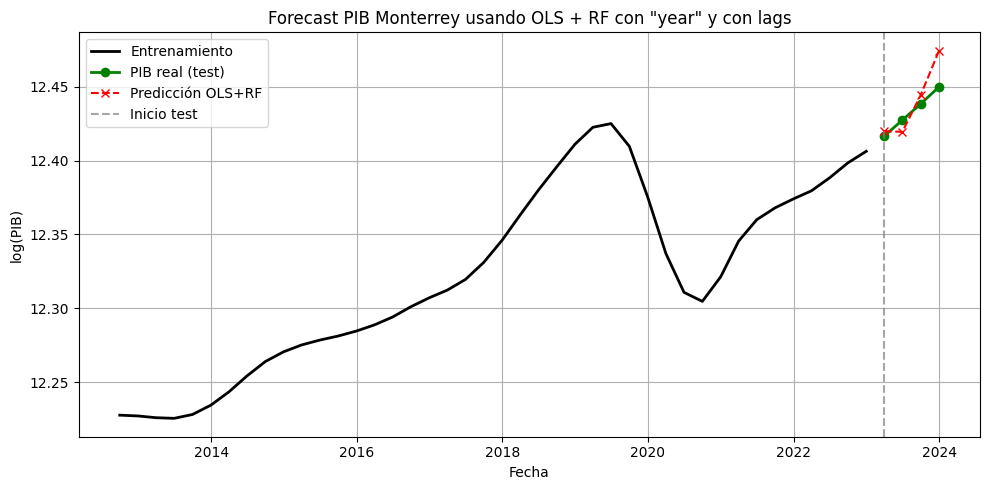

In [41]:
# -------- Forecast con modelo híbrido OLS + RF con year --------

mont_rad_pib["year"] = mont_rad_pib["fecha"].dt.year

# Crear lista de features con year (sin mutar medidas_base)
medidas_con_year = medidas_base.copy()
medidas_con_year.append("year")

# Selección de features correctas y consistentes
features = medidas_con_year  # Usamos las mismas features con year

# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['log_pib_mun_trend'].iloc[:-n_preds].astype(float)
    y_mun_test = df_mun['log_pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Escalar datos
scaler_X_forecast = StandardScaler()
scaler_y_forecast = StandardScaler()

X_train_scaled = scaler_X_forecast.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)

X_test_scaled = scaler_X_forecast.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

y_train_scaled = scaler_y_forecast.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Entrenar modelo OLS
X_train_ols = sm.add_constant(X_train_scaled)
ols_model_forecast = sm.OLS(y_train_scaled, X_train_ols).fit()
y_hat_ols_train = ols_model_forecast.predict(X_train_ols)
residuals_ols_forecast = y_train_scaled - y_hat_ols_train

# Entrenar RF en residuales
rf_forecast = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
rf_forecast.fit(X_train_scaled, residuals_ols_forecast)

# Predicciones
X_test_ols = sm.add_constant(X_test_scaled)
y_pred_ols_scaled = ols_model_forecast.predict(X_test_ols)
y_pred_rf_scaled = rf_forecast.predict(X_test_scaled)
y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled

# Desescalar
y_pred = scaler_y_forecast.inverse_transform(
    y_pred_hybrid_scaled.values.reshape(-1, 1)
).ravel()

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast (log): {rmse:.6f}")
print(f"MSE forecast (log): {mse:.6f}")
print(f"MAE forecast (log): {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción OLS+RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando OLS + RF con "year" y con lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
